# Design and implementation of the codec

In [ ]:
from pathlib import Path
from typing import Dict

import numpy as np
import pandas as pd
import soundfile as sf
from matplotlib import pyplot as plt
from scipy.linalg import solve_toeplitz
from scipy.signal import get_window, lfilter

# Selection of the parameter values

In [3]:
LPC_ORDER = 10
ACORR_WIN = "hamming"  # tukey is better but ok
FRAME_LENGTH = 0.025
FFT_N = 1024

In [4]:
DATA_MALE_PATH = Path("Male_sentences_8kHz")
DATA_FEMALE_PATH = Path("Female_sentences_8kHz")
EXAMPLE_MALE_PATH = DATA_MALE_PATH / "si745_8kHz.wav"
EXAMPLE_FEMALE_PATH = DATA_FEMALE_PATH / "si747_8kHz.wav"

# LP analysis and synthesis without quantization

Small change from the original suggestion - store the warm-up samples inside the residual as this makes teh whole process easier and doesn't involve the use of zi or other operations including Z-transforms that might affect accuracy

In [5]:
def autocorr(signal: np.array, target_len: int) -> np.array:
    """
    Computes autocorrelation
    :param signal: signal to be autocorrelated
    :param target_len: number of coefficients
    :return: autocorrelation coefficients
    """
    return np.asarray([signal[:len(signal) - i].dot(signal[i:]) for i in range(target_len)])


def calculate_lpc_coefficients(signal: np.ndarray, order: int) -> np.ndarray:
    """
    Calculates LPC coefficents
    :param signal: input signal to calculate LPC coefficients from
    :param order: LPC order
    :return: LPC coefficients as filter parameters suitable for lfilter 
    """
    window = get_window(ACORR_WIN, len(signal))
    r = autocorr(signal * window, order + 1)

    lpc_raw = solve_toeplitz(r[:-1], r[1:], check_finite=False)

    # add a x1 coefficient for the current sample and invert the LPC so we subtract the predicted sum
    # using LPC with these coefficients will result in the residual without any necessary subtraction step
    # this also allows for inverse filtering even without setting initial values for the delay line
    # (since the warm-up samples are still in the residual - see beginning of example frame residual)
    return np.pad(-lpc_raw, (1, 0), constant_values=1)


def compute_residual(signal: np.ndarray, lpc_c: np.ndarray) -> np.ndarray:
    return lfilter(lpc_c, [1], signal)


def restore_signal(signal: np.ndarray, lpc_c: np.ndarray) -> np.ndarray:
    return lfilter([1], lpc_c, signal)

In [6]:
def lpc_analysis(frame: np.ndarray) -> (np.ndarray, np.ndarray):
    lpc_c = calculate_lpc_coefficients(frame, LPC_ORDER)
    residual = compute_residual(frame, lpc_c)
    return residual, lpc_c


def lpc_synthesis(frame_residual: np.ndarray, lpc_c: np.ndarray) -> np.ndarray:
    return restore_signal(frame_residual, lpc_c)


def process_frame(frame: np.ndarray) -> Dict[str, np.ndarray]:
    resid, lpc_c = lpc_analysis(frame)
    restored = lpc_synthesis(resid, lpc_c)
    return {"Frame": frame, "LPC Coefficients": lpc_c, "Residual": resid, "Synthetized Frame": restored}

In [7]:
def lpc(file_path: Path):
    with sf.SoundFile(file_path, "r") as f:
        sr = f.samplerate
        frames = list(f.blocks(blocksize=int(sr * FRAME_LENGTH), dtype="float64"))

    if len(frames[0].shape) != 1:
        raise RuntimeError("This codec only supports mono audio")

    for i, frame in enumerate(frames):
        process_frame(frame)

    return pd.DataFrame.from_records([process_frame(f) for f in frames])


df = lpc(EXAMPLE_MALE_PATH)

### Plot one nice speech frame for comparison

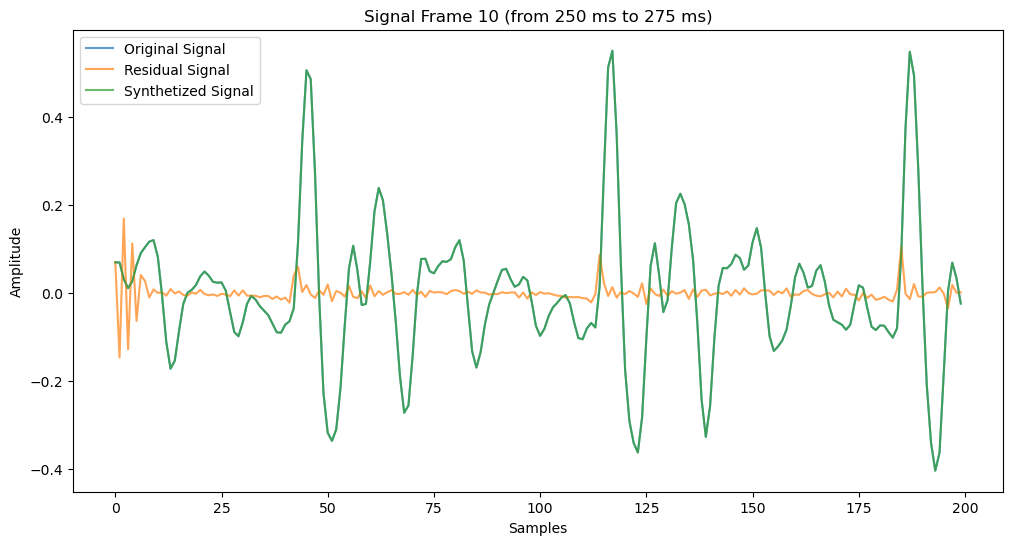

In [17]:
example_frame_idx = 10

plt.figure(figsize=(12, 6))
plt.plot(df.loc[example_frame_idx, "Frame"], label="Original Signal", alpha=0.7)
plt.plot(df.loc[example_frame_idx, "Residual"], label="Residual Signal", alpha=0.7)
plt.plot(df.loc[example_frame_idx, "Synthetized Frame"], label="Synthetized Signal", alpha=0.7)
plt.legend()
plt.title(f"Signal Frame {example_frame_idx} (from "
          f"{example_frame_idx * FRAME_LENGTH * 1000:.0f} ms to "
          f"{(example_frame_idx + 1) * FRAME_LENGTH * 1000:.0f} ms)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

### Plot whole signal as the assignment requires

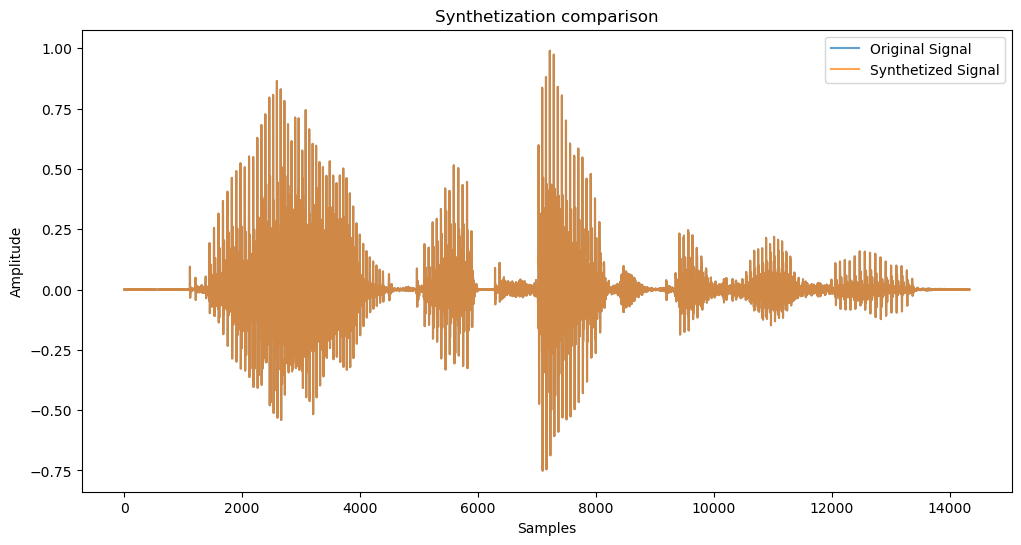

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(np.concatenate(df["Frame"]), label="Original Signal", alpha=0.7)
plt.plot(np.concatenate(df["Synthetized Frame"]), label="Synthetized Signal", alpha=0.7)
plt.legend()
plt.title("Synthetization comparison")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

### Differences
Just to illustrate the similarity better, let's plot the max difference between the original and the synthetized signal in each frame 

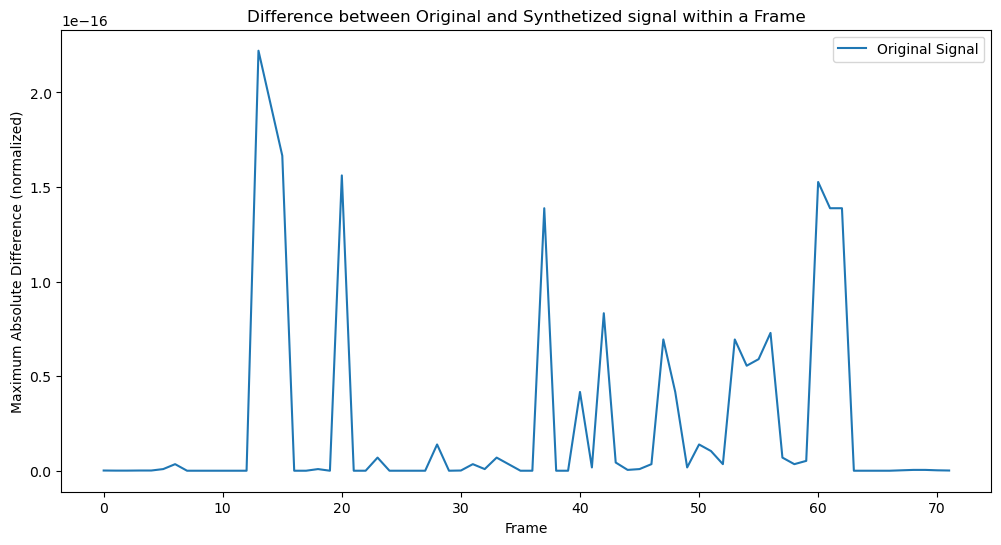

In [28]:
plt.figure(figsize=(12, 6))
plt.plot(df.apply(lambda x: abs(x["Frame"] - x["Synthetized Frame"]).max(), axis=1), label="Original Signal")
plt.legend()
plt.title("Difference between Original and Synthetized signal within a Frame")
plt.xlabel("Frame")
plt.ylabel("Maximum Absolute Difference (normalized)")
plt.show()